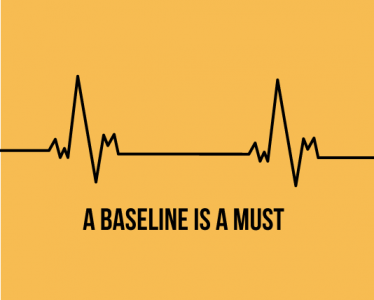

## 🤏 Build the simple baseline model for comparison

### 🎒 Packages

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_colwidth', None)
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.svm import LinearSVC
import wandb


### 🚙 Utilities

In [2]:
train_path = Path("..") / "data" / "train" / "train.tsv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / "data" / "test" / "train.tsv"

### 📊 Data

In [3]:
baseline_df = pd.read_csv(train_path, sep="\t")
baseline_df.head()

,PhraseId,SentenceId,Phrase,Sentiment
0,1,1,"A series of escapades demonstrating the adage that what is good for the goose is also good for the gander , some of which occasionally amuses but none of which amounts to much of a story .",1
1,2,1,A series of escapades demonstrating the adage that what is good for the goose,2
2,3,1,A series,2
3,4,1,A,2
4,5,1,series,2


In [4]:
vectorizer_config = {
    "type": "TF-IDF",
    "lowercase": True,
    "stop_words": "english",
    "ngram_range": (1, 2),
    "min_df": 2
}

#### ⚾ Try baseline with Logistic Regression

In [5]:
X = baseline_df["Phrase"]
y = baseline_df["Sentiment"]

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

In [ ]:
vectorizer = TfidfVectorizer(
    lowercase=vectorizer_config["type"],
    stop_words=vectorizer_config["stop_words"],
    ngram_range=vectorizer_config["ngram_range"],
    min_df=vectorizer_config["min_df"]
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

In [22]:
wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="ML_LogReg",
    name="logreg_tfidf_v1",
    config={
        "task": "sentiment_classification",
        "num_classes": 5,
        "model": "LogisticRegression",
        "vectorizer": vectorizer_config,
        "C": 1.0,
        "max_iter": 500,
        "dataset": "Rotten Tomatoes"
    }
)

lr = LogisticRegression(max_iter=500)
lr.fit(X_train_vec, y_train)

y_pred = lr.predict(X_val_vec)

acc = accuracy_score(y_val, y_pred)
f1_macro = f1_score(y_val, y_pred, average="macro")
f1_weighted = f1_score(y_val, y_pred, average="weighted")

# Log metrics
wandb.log({
    "val_accuracy": acc,
    "val_f1_macro": f1_macro,
    "val_f1_weighted": f1_weighted
})

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/zun/.netrc.
wandb: Currently logged in as: trungdunglebui17112004 (trungdunglebui17112004-ho-chi-minh-city-university-of-te) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [23]:
y_pred = lr.predict(X_val_vec)

print("Accuracy:", accuracy_score(y_val, y_pred))
print(classification_report(y_val, y_pred))

Accuracy: 0.6460335768294245
              precision    recall  f1-score   support

           0       0.58      0.18      0.28       707
           1       0.56      0.38      0.45      2727
           2       0.67      0.88      0.77      7958
           3       0.59      0.49      0.54      3293
           4       0.69      0.27      0.39       921

    accuracy                           0.65     15606
   macro avg       0.62      0.44      0.49     15606
weighted avg       0.63      0.65      0.62     15606



#### ⚾ Try baseline with SVM

In [8]:
wandb.init(
    entity="trungdunglebui17112004-ho-chi-minh-city-university-of-te",
    project="sentiment-analysis-on-movie-reviews",
    group="ML_SVM",
    name="svm_tfidf_v1",
    config={
        "task": "sentiment_classification",
        "num_classes": 5,
        "model": "LinearSVC",
        "vectorizer": vectorizer_config,
        "dataset": "Rotten Tomatoes"
    }
)

svm = LinearSVC()
svm.fit(X_train_vec, y_train)

y_pred = svm.predict(X_val_vec)

acc = accuracy_score(y_val, y_pred)
f1_macro = f1_score(y_val, y_pred, average="macro")
f1_weighted = f1_score(y_val, y_pred, average="weighted")

wandb.log({
    "val_accuracy": acc,
    "val_f1_macro": f1_macro,
    "val_f1_weighted": f1_weighted
})

wandb.finish()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/zun/.netrc.


wandb: Currently logged in as: trungdunglebui17112004 (trungdunglebui17112004-ho-chi-minh-city-university-of-te) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


val_accuracy,▁
val_f1_macro,▁
val_f1_weighted,▁
val_accuracy,0.65776
val_f1_macro,0.54229
val_f1_weighted,0.64909
